In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/clean_energy_data.csv")

print(df.shape)
df.head()

(7696, 130)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,Afghanistan,1990,AFG,12045664.0,1.306598e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1991,AFG,12238879.0,1.204736e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1992,AFG,13278983.0,1.267754e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1993,AFG,14943175.0,9.834582e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1994,AFG,16250800.0,7.919856e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7696 entries, 0 to 7695
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 7.6+ MB


In [4]:
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,7696.000000,7.648000e+03,5.409000e+03,1121.000000,3574.000000,3593.000000,3594.000000,5676.000000,5676.000000,5650.000000,...,6153.000000,2765.000000,1742.000000,2762.000000,2765.000000,5991.000000,5991.000000,2765.000000,5965.000000,2765.000000
mean,2007.267282,3.179009e+07,4.900445e+11,60.908949,0.358130,80.139869,5.186598,69.619707,1.891949,1.983865,...,1.201723,0.373249,170.914797,2.196913,17.852661,88.841139,3.777021,350.818998,1.737978,0.928719
std,10.176833,1.268326e+08,1.704837e+12,335.101660,3.086099,222.721905,31.378100,204.717622,9.060096,5.636912,...,3.627877,1.029944,3282.237565,15.691555,105.958298,319.689458,33.504627,950.844900,5.385771,2.416808
min,1990.000000,1.776000e+03,2.571720e+08,-100.000000,-37.549011,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-43.796021,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1998.000000,6.716150e+05,1.934660e+10,-1.700601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.215308,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2007.000000,5.527480e+06,6.326133e+10,7.455047,0.000000,0.000000,0.000000,0.224753,0.010000,0.042853,...,0.000000,0.000983,16.070391,0.000000,0.051075,0.000000,0.000000,2.602089,0.000000,0.009956
75%,2016.000000,2.027575e+07,2.913339e+11,28.458622,0.000000,17.022732,0.374273,36.824836,0.340000,1.428571,...,0.285459,0.109429,44.892081,0.327071,3.165834,12.160355,0.090000,149.672775,0.363636,0.528995
max,2025.000000,1.463866e+09,2.696602e+13,5659.328125,60.875458,2587.707520,523.642212,2450.790527,213.009995,77.586205,...,50.000000,9.881398,133237.328125,463.419189,2431.804932,4015.415771,1135.439941,9315.287109,58.214485,26.085308


In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing.head(30)

nuclear_cons_change_pct             6643
biofuel_cons_change_pct             6575
solar_cons_change_pct               6110
wind_cons_change_pct                5954
other_renewables_cons_change_pct    5739
coal_prod_change_pct                5562
hydro_cons_change_pct               5259
coal_cons_change_pct                5112
low_carbon_cons_change_pct          5081
renewables_cons_change_pct          5081
gas_cons_change_pct                 5069
gas_prod_change_pct                 4952
oil_cons_change_pct                 4934
oil_cons_change_twh                 4934
fossil_cons_change_twh              4934
fossil_cons_change_pct              4934
low_carbon_cons_change_twh          4934
coal_cons_change_twh                4934
hydro_cons_change_twh               4934
wind_cons_change_twh                4934
other_renewables_cons_change_twh    4934
gas_cons_change_twh                 4934
solar_cons_change_twh               4934
renewables_cons_change_twh          4934
electricity_shar

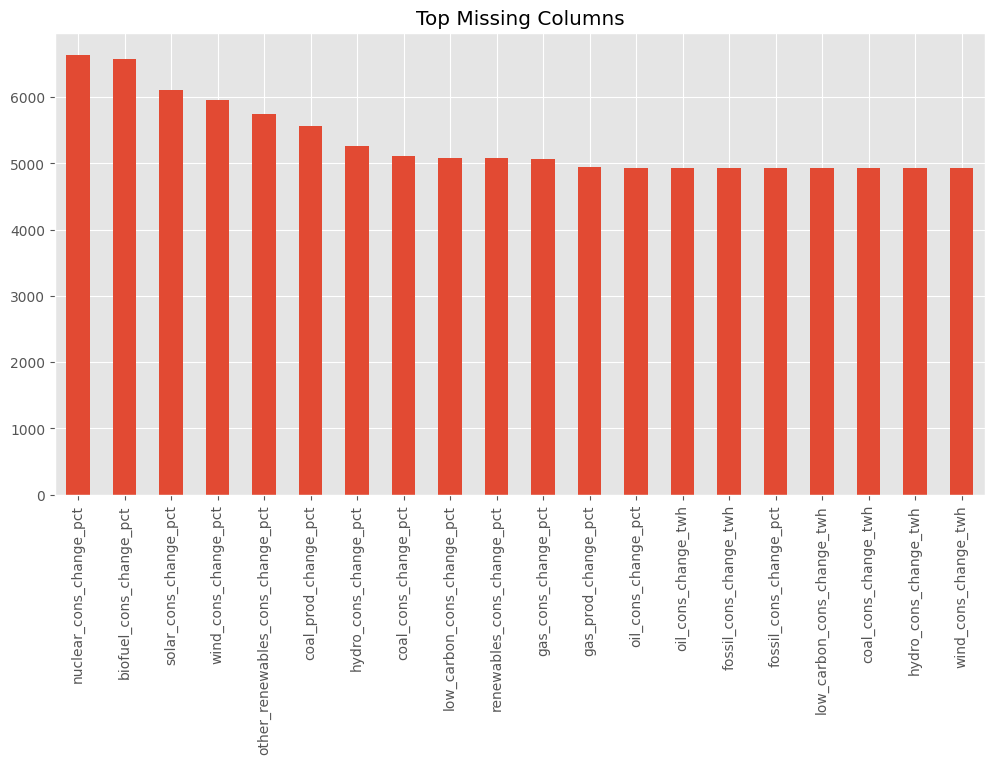

In [6]:
missing = missing[missing > 0]

plt.figure(figsize=(12,6))

missing.head(20).plot(kind="bar")

plt.title("Top Missing Columns")
plt.show()

In [7]:
top10 = (
    df.groupby("country")["primary_energy_consumption"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

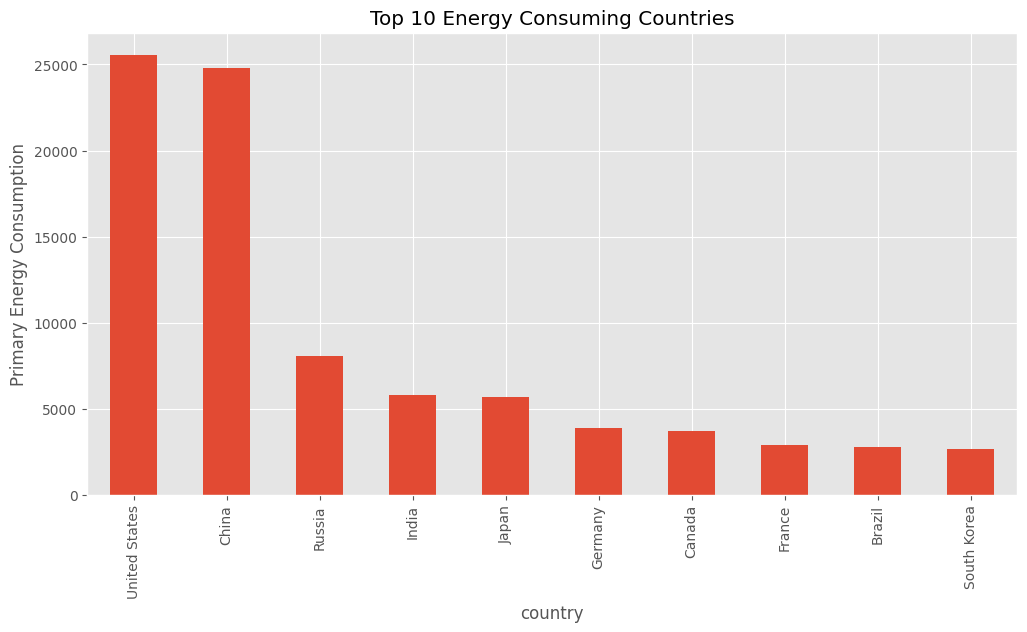

In [8]:
plt.figure(figsize=(12,6))

top10.plot(kind="bar")

plt.title("Top 10 Energy Consuming Countries")
plt.ylabel("Primary Energy Consumption")

plt.show()

In [9]:
global_energy = (
    df.groupby("year")
      ["primary_energy_consumption"]
      .sum()
      .reset_index()
)

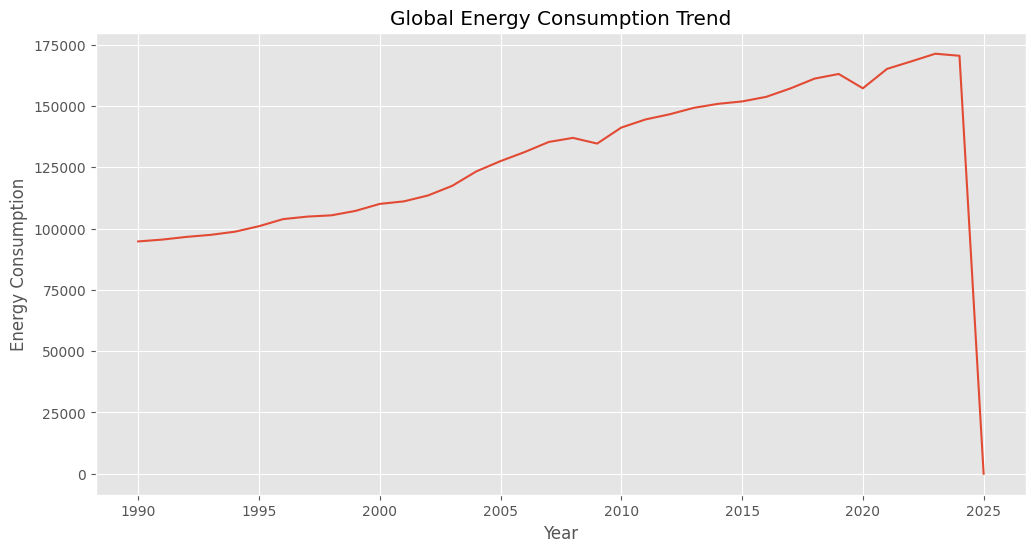

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    global_energy["year"],
    global_energy["primary_energy_consumption"]
)

plt.title("Global Energy Consumption Trend")
plt.xlabel("Year")
plt.ylabel("Energy Consumption")

plt.show()

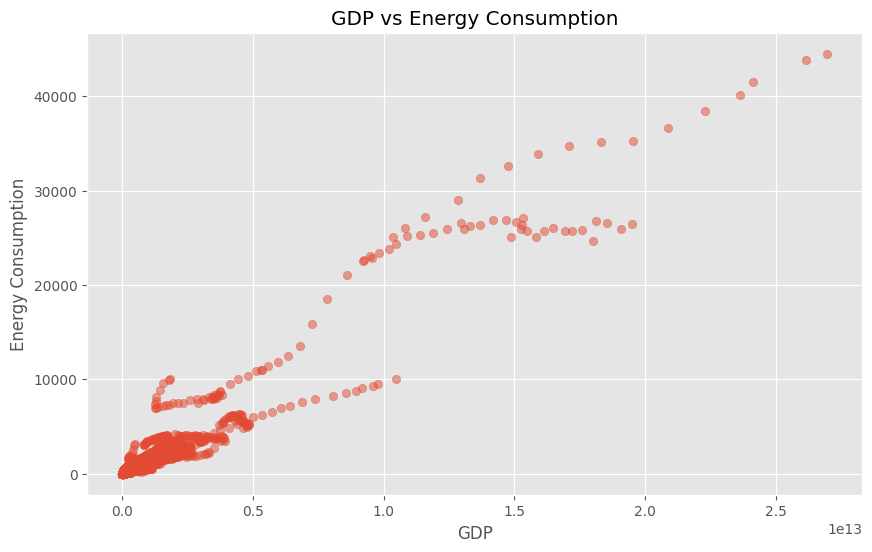

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["gdp"],
    df["primary_energy_consumption"],
    alpha=0.5
)

plt.xlabel("GDP")
plt.ylabel("Energy Consumption")

plt.title("GDP vs Energy Consumption")

plt.show()

In [12]:
renewables = (
    df.groupby("year")
      ["renewables_share_energy"]
      .mean()
      .reset_index()
)

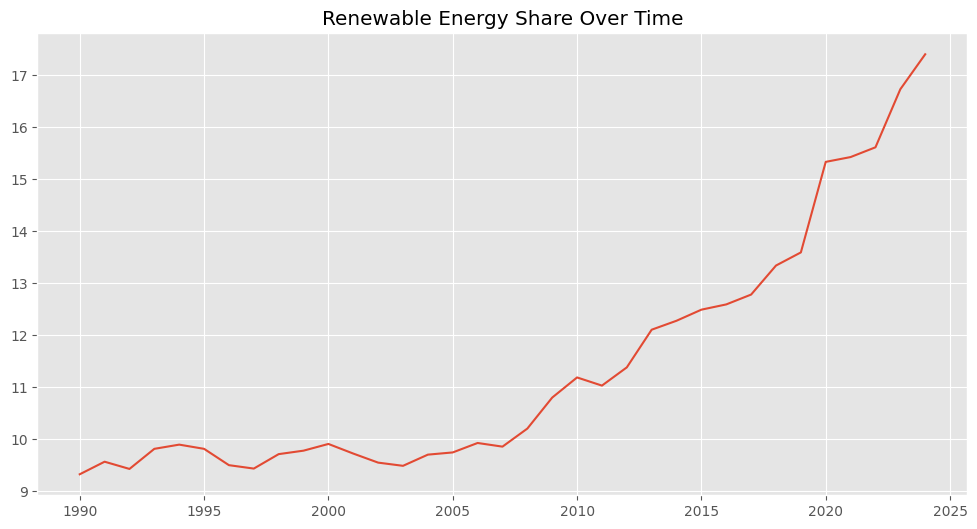

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    renewables["year"],
    renewables["renewables_share_energy"]
)

plt.title("Renewable Energy Share Over Time")

plt.show()

In [14]:
corr_features = [
    "population",
    "gdp",
    "electricity_generation",
    "electricity_demand",
    "coal_consumption",
    "gas_consumption",
    "oil_consumption",
    "renewables_consumption",
    "low_carbon_consumption",
    "greenhouse_gas_emissions",
    "primary_energy_consumption"
]

In [15]:
corr_matrix = (
    df[corr_features]
      .corr()
)

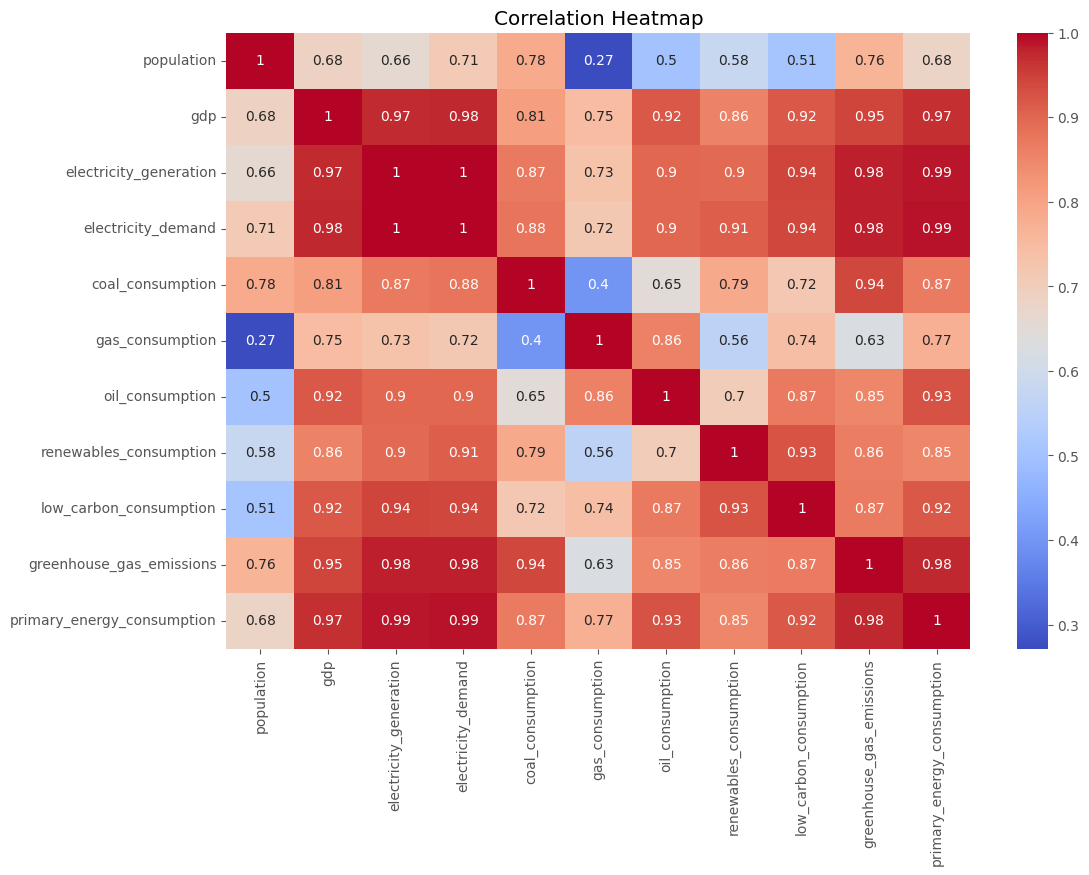

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
latest_year = df["year"].max()

latest_df = df[
    df["year"] == latest_year
]

In [18]:
fig = px.choropleth(
    latest_df,
    locations="iso_code",
    color="primary_energy_consumption",
    hover_name="country",
    title=f"Energy Consumption ({latest_year})"
)

fig.show()